# Claim 2b: task-vector recovery accuracy tracks ICL accuracy across input manipulations

Functional-relevance claim: when we extract a task vector from a (possibly manipulated) ICL prompt and patch it into a zero-shot query, does the resulting accuracy track the ICL accuracy of the original manipulated prompt? If yes, the task vector is functionally responsible for the input manipulations' behavioral effects.

**Procedure per prompt per condition:**
1. Build the manipulated ICL prompt (claim-1 conditions).
2. Extract residual stream at the last demo's arrow position at a fixed layer (default: middle of network).
3. Build a zero-shot query: `{query_input} → ` with no demos.
4. Patch the extracted residual into the zero-shot prompt at the position right before the answer is predicted, at the same layer.
5. Score the next-token logits: accuracy and rank of correct answer.

**Comparison to claim 1:** plot side-by-side TV-recovery accuracy and full-ICL accuracy across the same conditions. If they track, claim 2b is supported.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, pickle, random, seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from math import sqrt
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)

rng = random.Random(42)
PATCH_LAYER = 12  # standard task-vector layer for Llama-3.2-3B-ish models

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-24 15:58:14.142081: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.12it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Build pools and donor mappings (same as claim 2a)

In [2]:
W_E = model.W_E.detach()

input_pool_all = []
input_pool_all_tokids = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts']:
        for inp, _ in pdata['demo_pairs']:
            input_pool_all.append(inp)
            toks = model.to_tokens(' ' + inp, prepend_bos=False)[0]
            input_pool_all_tokids.append(toks[0].item())
mean_input_embed = W_E[input_pool_all_tokids].mean(dim=0)

task_list = sorted(all_splits.keys())
donor_task = {t: task_list[(i + len(task_list) // 2) % len(task_list)]
              for i, t in enumerate(task_list)}

task_input_tokids = {t: [model.to_tokens(' ' + inp, prepend_bos=False)[0, 0].item()
                          for pdata in splits['icl_prompts']
                          for inp, _ in pdata['demo_pairs']]
                     for t, splits in all_splits.items()}
task_mean_emb = {t: W_E[ids].mean(dim=0).float() for t, ids in task_input_tokids.items()}

related_donor_task = {}
for t in task_list:
    t_emb = task_mean_emb[t]
    best_sim, best_other = -float('inf'), None
    for other in task_list:
        if other == t: continue
        sim = torch.nn.functional.cosine_similarity(t_emb, task_mean_emb[other], dim=0).item()
        if sim > best_sim:
            best_sim, best_other = sim, other
    related_donor_task[t] = best_other

## Patching helpers

In [3]:
def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions:
            emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

def get_query_arrow_position(model, prompt):
    """Return the position of the LAST arrow token in the prompt — i.e., the query arrow,
    which sits between the query input and where the answer would be generated."""
    # Find arrow token id. The standard separator is ' →' (space + arrow).
    arrow_tok = model.to_tokens(' →', prepend_bos=False)[0, 0].item()
    tokens = model.to_tokens(prompt, prepend_bos=True)[0]
    arrow_positions = (tokens == arrow_tok).nonzero().squeeze(-1).tolist()
    if not arrow_positions: return None
    return arrow_positions[-1]

RESID_FILTER = lambda name: 'resid_post' in name

def extract_tv_at_layer(tokens, arrow_pos, layer, hooks=None):
    with torch.no_grad():
        if hooks:
            with model.hooks(fwd_hooks=hooks):
                _, cache = model.run_with_cache(tokens, names_filter=lambda n: f'resid_post' in n)
        else:
            _, cache = model.run_with_cache(tokens, names_filter=lambda n: f'resid_post' in n)
    return cache['resid_post', layer][0, arrow_pos].cpu().float().numpy()

def build_zeroshot(query_input):
    return f'{query_input} \u2192'

def answer_rank(model, logits, answer):
    ans_tok = model.to_tokens(' ' + answer, prepend_bos=False)[0, 0].item()
    return int((logits > logits[ans_tok]).sum().item())

## Setup

In [8]:
CONDS = ['orig', 'shuffled', 'related_wrong_task_inputs', 'wrong_task_inputs',
         'random_from_input_pool', 'mean_embed', 'star', 'query_only']

all_jobs = [(task_name, splits, p_idx, pdata)
            for task_name, splits in all_splits.items()
            for p_idx, pdata in enumerate(splits['icl_prompts'][:10])]

print(f'CONDS = {CONDS}')
print(f'all_jobs = {len(all_jobs)} (task, prompt) pairs')

CONDS = ['orig', 'shuffled', 'related_wrong_task_inputs', 'wrong_task_inputs', 'random_from_input_pool', 'mean_embed', 'star', 'query_only']
all_jobs = 200 (task, prompt) pairs


## Collect TV-recovery accuracy and rank per condition

Uses the existing `eval_patched_resid` from utils, which patches a residual vector into a zero-shot prompt at a specified layer and returns the next-token logits.

In [6]:
tv_correct = {c: {L: [] for L in range(n_layers)} for c in CONDS}
tv_rank    = {c: {L: [] for L in range(n_layers)} for c in CONDS}
prompt_task = []

pbar = tqdm(all_jobs, desc='Prompts')
cur_task = None
for task_name, splits, p_idx, pdata in pbar:
    if task_name != cur_task:
        cur_task = task_name
        donor_prompts         = all_splits[donor_task[task_name]]['icl_prompts']
        related_donor_prompts = all_splits[related_donor_task[task_name]]['icl_prompts']
        eval_data = splits.get('eval_data', None)
    pbar.set_postfix_str(f'{task_name.split("/")[-1][:18]} p{p_idx}')
    
    demos = pdata['demo_pairs']
    ans = pdata.get('query_output')
    if ans is None: continue
    
    # Held-out query: use the query from a DIFFERENT prompt of the same task
    if eval_data is not None and len(eval_data) > 0:
        eq = eval_data[p_idx % len(eval_data)]
        zs_query_input  = eq.get('query_input', None)
        zs_query_output = eq.get('query_output', None)
    else:
        other_idx = (p_idx + 1) % len(splits['icl_prompts'])
        if other_idx == p_idx:
            other_idx = (p_idx + 2) % len(splits['icl_prompts'])
        other_pdata = splits['icl_prompts'][other_idx]
        zs_query_input  = other_pdata['query_input']
        zs_query_output = other_pdata.get('query_output')
    
    if zs_query_input is None or zs_query_output is None:
        continue
    
    outputs = [o for _, o in demos]
    inputs  = [i for i, _ in demos]
    inputs_shuffled = inputs.copy(); rng.shuffle(inputs_shuffled)
    
    donor_pdata = donor_prompts[p_idx % len(donor_prompts)]
    inputs_wrong = [i for i, _ in donor_pdata['demo_pairs']]
    if len(inputs_wrong) < len(demos):
        inputs_wrong = (inputs_wrong * ((len(demos) // len(inputs_wrong)) + 1))[:len(demos)]
    inputs_wrong = inputs_wrong[:len(demos)]
    
    rel_pdata = related_donor_prompts[p_idx % len(related_donor_prompts)]
    inputs_related = [i for i, _ in rel_pdata['demo_pairs']]
    if len(inputs_related) < len(demos):
        inputs_related = (inputs_related * ((len(demos) // len(inputs_related)) + 1))[:len(demos)]
    inputs_related = inputs_related[:len(demos)]
    
    inputs_random = [rng.choice(input_pool_all) for _ in range(len(demos))]
    
    prompts = {
        'orig':       pdata['prompt'],
        'query_only': f"{pdata['query_input']} \u2192",
        'shuffled': build_icl_prompt(list(zip(inputs_shuffled, outputs)), pdata['query_input']),
        'related_wrong_task_inputs': build_icl_prompt(list(zip(inputs_related, outputs)), pdata['query_input']),
        'wrong_task_inputs':         build_icl_prompt(list(zip(inputs_wrong, outputs)), pdata['query_input']),
        'random_from_input_pool':    build_icl_prompt(list(zip(inputs_random, outputs)), pdata['query_input']),
        'star':     build_icl_prompt([('*', o) for o in outputs], pdata['query_input']),
    }
    tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
    arrow_pos = {k: get_query_arrow_position(model, prompts[k]) for k in prompts}
    if any(a is None for a in arrow_pos.values()): continue
    
    zs_prompt = f"{zs_query_input} \u2192"
    
    for k in ['orig', 'query_only', 'shuffled', 'related_wrong_task_inputs',
              'wrong_task_inputs', 'random_from_input_pool', 'star']:
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens[k], names_filter=lambda n: 'resid_post' in n)
        for L in range(n_layers):
            tv = cache['resid_post', L][0, arrow_pos[k]].cpu().float().numpy()
            logits = eval_patched_resid(model, zs_prompt, tv, L)
            tv_correct[k][L].append(int(check_correct(model, logits, zs_query_output)))
            tv_rank[k][L].append(answer_rank(model, logits, zs_query_output))
        del cache
    
    per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
    input_positions = [p for d in per_demo_orig for p in d.get('input_positions', [])]
    hook = [('hook_embed', make_embed_hook(input_positions, mean_input_embed))]
    with torch.no_grad(), model.hooks(fwd_hooks=hook):
        _, cache = model.run_with_cache(tokens['orig'], names_filter=lambda n: 'resid_post' in n)
    for L in range(n_layers):
        tv = cache['resid_post', L][0, arrow_pos['orig']].cpu().float().numpy()
        logits = eval_patched_resid(model, zs_prompt, tv, L)
        tv_correct['mean_embed'][L].append(int(check_correct(model, logits, zs_query_output)))
        tv_rank['mean_embed'][L].append(answer_rank(model, logits, zs_query_output))
    del cache
    
    prompt_task.append(task_name)
    torch.cuda.empty_cache()

for c in CONDS:
    for L in range(n_layers):
        tv_correct[c][L] = np.array(tv_correct[c][L])
        tv_rank[c][L]    = np.array(tv_rank[c][L])
prompt_task = np.array(prompt_task)
total_n = len(prompt_task)
print(f'\nTotal prompts scored: {total_n}, layers: {n_layers}')

Prompts: 100%|██████████| 200/200 [38:29<00:00, 11.55s/it, it_en p9]             


Total prompts scored: 200, layers: 28


## Marginal TV-recovery accuracy plot

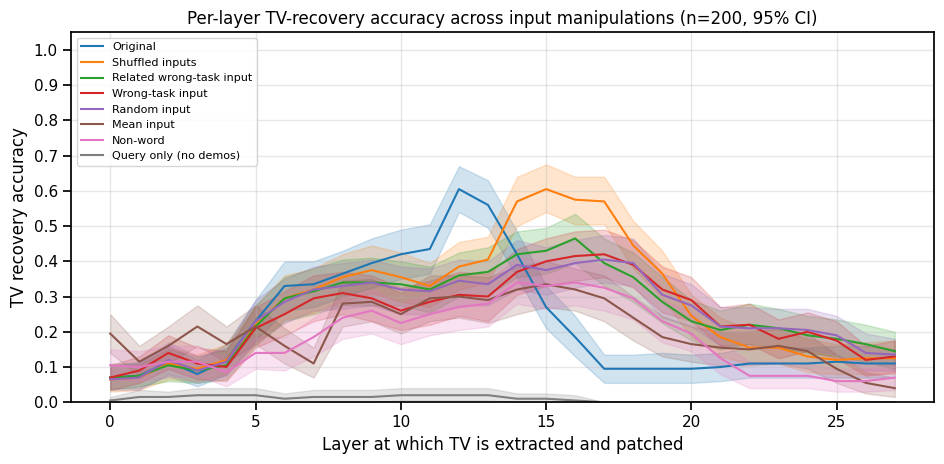

In [7]:
tick_map = {
    'orig': 'Original',
    'shuffled': 'Shuffled inputs',
    'related_wrong_task_inputs': 'Related wrong-task input',
    'wrong_task_inputs': 'Wrong-task input',
    'random_from_input_pool': 'Random input',
    'mean_embed': 'Mean input',
    'star': 'Non-word',
    'query_only': 'Query only (no demos)',
}
order_keys = CONDS

rows = []
for c in CONDS:
    for L in range(n_layers):
        for v in tv_correct[c][L]:
            rows.append({'Condition': tick_map[c], 'Layer': L, 'Recovery': v})
df_layer = pd.DataFrame(rows)
label_order = [tick_map[c] for c in CONDS]

fig, ax = plt.subplots(figsize=(6.4*1.5, 4.8))
sns.lineplot(data=df_layer, x='Layer', y='Recovery', hue='Condition', hue_order=label_order,
             palette='tab10', errorbar=('ci', 95), ax=ax)
ax.set_ylabel('TV recovery accuracy')
ax.set_xlabel('Layer at which TV is extracted and patched')
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_title(f'Per-layer TV-recovery accuracy across input manipulations (n={total_n}, 95% CI)')
ax.grid(True, alpha=0.3)
ax.legend(title='', loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Marginal TV-recovery rank plot

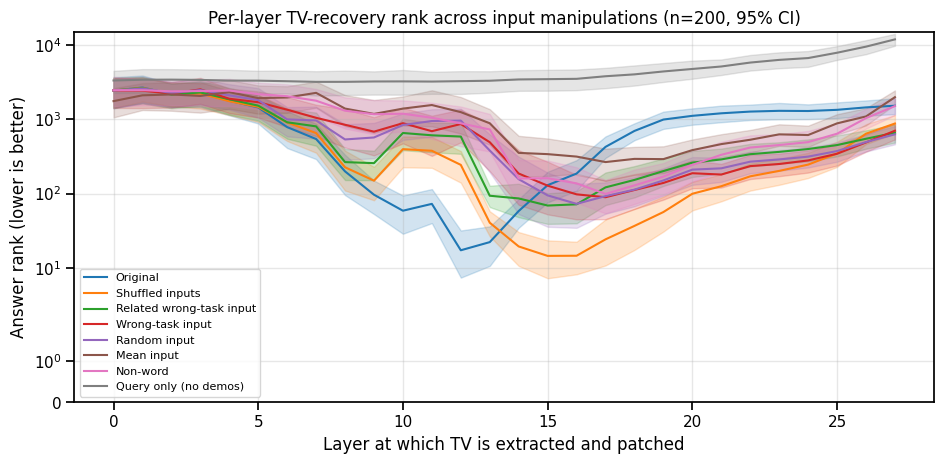

In [8]:
rows = []
for c in CONDS:
    for L in range(n_layers):
        for v in tv_rank[c][L]:
            rows.append({'Condition': tick_map[c], 'Layer': L, 'Rank': v})
df_rank = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.4*1.5, 4.8))
sns.lineplot(data=df_rank, x='Layer', y='Rank', hue='Condition', hue_order=label_order,
             palette='tab10', errorbar=('ci', 95), ax=ax)
ax.set_ylabel('Answer rank (lower is better)')
ax.set_xlabel('Layer at which TV is extracted and patched')
ax.set_yscale('symlog')
ax.set_ylim(bottom=0)
ax.set_title(f'Per-layer TV-recovery rank across input manipulations (n={total_n}, 95% CI)')
ax.grid(True, alpha=0.3)
ax.legend(title='', loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

## Per-task panel: TV-recovery accuracy

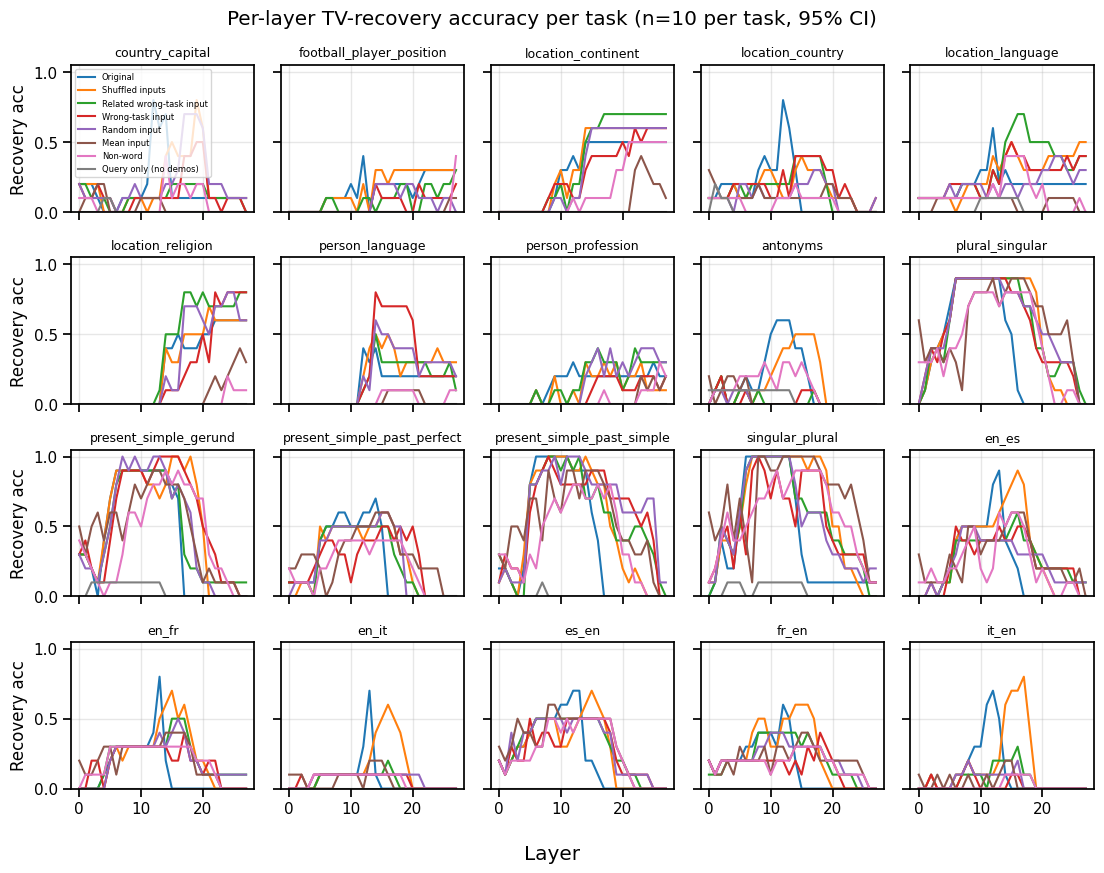

In [9]:
task_list_sorted = sorted(set(prompt_task))
n_cols = 5
n_rows = int(np.ceil(len(task_list_sorted) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4*1.75, 2.2*n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, task_list_sorted):
    mask = prompt_task == t
    rows = []
    for c in CONDS:
        for L in range(n_layers):
            for v in tv_correct[c][L][mask]:
                rows.append({'Condition': tick_map[c], 'Layer': L, 'Recovery': v})
    df_t = pd.DataFrame(rows)
    sns.lineplot(data=df_t, x='Layer', y='Recovery', hue='Condition', hue_order=label_order,
                 palette='tab10', errorbar=None, ax=ax, legend=(ax is axes[0]))
    ax.set_title(t.split('/')[-1], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Recovery acc' if ax in axes[::n_cols] else '')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].legend(title='', loc='upper left', fontsize=6)
for ax in axes[len(task_list_sorted):]:
    ax.set_visible(False)

fig.supxlabel('Layer')
fig.suptitle(f'Per-layer TV-recovery accuracy per task (n={mask.sum()} per task, 95% CI)')
plt.tight_layout(); plt.show()

## Pairwise differences (vs claim 1)

Same comparisons as claim 1's pairwise plot, computed on TV-recovery accuracy. For interpretation: compare side-by-side with claim 1's pairwise plot to see whether each input dimension contributes the same share of damage at the TV level as it does at the ICL level.

Best orig-recovery layer: 12 (acc=0.605)

Pairwise differences at layer 12:
Comparison                                                Δ mean       [95% bootstrap CI]
--------------------------------------------------------------------------------------------
orig − shuffled                              +0.220   [+0.160, +0.285]
shuffled − related_wrong_task_inputs             +0.025   [-0.020, +0.075]
related_wrong_task_inputs − wrong_task_inputs                     +0.055   [+0.015, +0.100]
wrong_task_inputs − random_from_input_pool                -0.040   [-0.080, +0.000]
random_from_input_pool − mean_embed                            +0.045   [+0.010, +0.080]
mean_embed − star                                  +0.030   [-0.010, +0.075]
star − query_only                            +0.250   [+0.190, +0.310]


/tmp/ipykernel_1880139/3089433494.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_df, y='Comparison', x='Mean', order=diff_df['Comparison'],


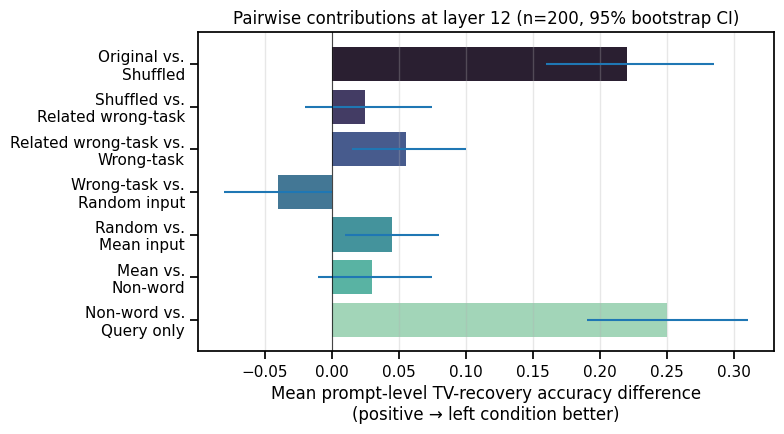

In [10]:
# Find the layer where 'orig' recovery is best (canonical task-vector layer for this dataset)
orig_per_layer = np.array([tv_correct['orig'][L].mean() for L in range(n_layers)])
best_layer = int(np.argmax(orig_per_layer))
print(f'Best orig-recovery layer: {best_layer} (acc={orig_per_layer[best_layer]:.3f})')

COMPARISONS = [
    ('orig', 'shuffled',                                    'Original vs.\nShuffled'),
    ('shuffled', 'related_wrong_task_inputs',               'Shuffled vs.\nRelated wrong-task'),
    ('related_wrong_task_inputs', 'wrong_task_inputs',      'Related wrong-task vs.\nWrong-task'),
    ('wrong_task_inputs', 'random_from_input_pool',         'Wrong-task vs.\nRandom input'),
    ('random_from_input_pool', 'mean_embed',                'Random vs.\nMean input'),
    ('mean_embed', 'star',                                  'Mean vs.\nNon-word'),
    ('star', 'query_only',                                  'Non-word vs.\nQuery only'),
]

N_BOOT = 5000
boot_rng = np.random.default_rng(42)

def bootstrap_diff_ci(a, b, n_boot=N_BOOT, ci=0.95):
    d = a - b
    n = len(d)
    means = np.empty(n_boot)
    for i in range(n_boot):
        idx = boot_rng.integers(0, n, n)
        means[i] = d[idx].mean()
    lo = np.percentile(means, 100 * (1 - ci) / 2)
    hi = np.percentile(means, 100 * (1 + ci) / 2)
    return d.mean(), lo, hi

diff_results = []
print(f'\nPairwise differences at layer {best_layer}:')
print(f'{"Comparison":<55} {"Δ mean":>8} {"[95% bootstrap CI]":>24}')
print('-' * 92)
for a, b, label in COMPARISONS:
    m, lo, hi = bootstrap_diff_ci(tv_correct[a][best_layer], tv_correct[b][best_layer])
    diff_results.append((a, b, label, m, lo, hi))
    print(f'{a} − {b:<35} {m:>+8.3f}   [{lo:+.3f}, {hi:+.3f}]')

diff_df = pd.DataFrame({
    'Comparison': [r[2] for r in diff_results],
    'Mean':       [r[3] for r in diff_results],
    'err_lo':     [r[3] - r[4] for r in diff_results],
    'err_hi':     [r[5] - r[3] for r in diff_results],
})

fig, ax = plt.subplots(figsize=(6.4*1.25, 4.5))
palette = sns.color_palette('mako', n_colors=len(diff_df))
sns.barplot(data=diff_df, y='Comparison', x='Mean', order=diff_df['Comparison'],
            palette=palette, linewidth=0, ax=ax)
ax.errorbar(x=diff_df['Mean'], y=np.arange(len(diff_df)),
            xerr=[diff_df['err_lo'], diff_df['err_hi']], fmt='none')
ax.axvline(0, color='black', lw=0.8, alpha=0.7)
ax.set_xlabel('Mean prompt-level TV-recovery accuracy difference\n(positive → left condition better)')
ax.set_ylabel('')
ax.set_title(f'Pairwise contributions at layer {best_layer} (n={total_n}, 95% bootstrap CI)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

# TV recovery with output→input heads ablated

Repeat the TV recovery analysis but with a fixed set of attention heads ablated (zeroed `hook_z`) for both the TV-extraction forward pass and the patched zero-shot forward passes.

Heads are scored by **average output-token attention to within-demo input positions** (the all-output-tokens version, not the last-token version), computed across Hendel ICL prompts. Top 10% by score are ablated. A matched random 10% serves as a control.

**Comparison to the unablated TV recovery:** if the ablated heads are causally responsible for TV formation, ablating them should drop TV recovery accuracy/log-prob substantially below unablated, while random-head ablation should leave it largely unchanged.

## Score output→input heads on Hendel ICL prompts

In [5]:
n_heads = model.cfg.n_heads

oi_score_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
oi_score_cnt = 0
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

scoring_jobs = [(t, splits, p_idx, pdata)
                for t, splits in all_splits.items()
                for p_idx, pdata in enumerate(splits['icl_prompts'])]

for t, splits, p_idx, pdata in tqdm(scoring_jobs, desc='Scoring heads'):
    demos = pdata['demo_pairs']
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
    
    oi_pairs = []
    for d in per_demo:
        ins  = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        for op in outs:
            for ip in ins:
                oi_pairs.append((op, ip))
    if not oi_pairs: continue
    
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
    
    for L in range(n_layers):
        patt = cache['pattern', L][0]
        for h in range(n_heads):
            s = 0.0
            for op, ip in oi_pairs:
                s += patt[h, op, ip].item()
            oi_score_sum[L, h] += s / len(oi_pairs)
    
    oi_score_cnt += 1
    del cache
    torch.cuda.empty_cache()

oi_score = oi_score_sum / max(oi_score_cnt, 1)

flat = [(L, h, oi_score[L, h]) for L in range(n_layers) for h in range(n_heads)]
flat.sort(key=lambda x: -x[2])
top10pct_n = max(1, int(0.10 * len(flat)))
top10_heads = [(L, h) for L, h, s in flat[:top10pct_n]]

import random as _random
_rng = _random.Random(0)
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]
top10_set = set(top10_heads)
rand10_heads = _rng.sample([p for p in all_pairs if p not in top10_set], top10pct_n)

print(f'Scored {oi_score_cnt} prompts')
print(f'Top 10 heads by avg-output→input score:')
for L, h, s in flat[:10]:
    print(f'  L{L:2d}H{h:2d}: {s:.4f}')
print(f'\nWill ablate {top10pct_n} heads (top 10%) plus matched random 10% as control')

Scoring heads: 100%|██████████| 1000/1000 [06:55<00:00,  2.40it/s]

Scored 1000 prompts
Top 10 heads by avg-output→input score:
  L 5H 3: 0.2002
  L10H10: 0.1700
  L 4H14: 0.1407
  L 7H 7: 0.1296
  L13H13: 0.1287
  L 7H18: 0.1254
  L 7H20: 0.1117
  L 7H19: 0.1082
  L13H 9: 0.1074
  L12H 1: 0.1072

Will ablate 67 heads (top 10%) plus matched random 10% as control


## Ablation hook helpers

In [6]:
from collections import defaultdict

def heads_by_layer_from(head_list):
    d = defaultdict(list)
    for L, h in head_list:
        d[L].append(h)
    return d

def make_ablation_hooks(heads_by_layer):
    fwd_hooks = []
    for L, h_list in heads_by_layer.items():
        def hook(z, hook, _h_list=h_list):
            for h in _h_list:
                z[0, :, h, :] = 0
            return z
        fwd_hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return fwd_hooks

ablation_hooks_top10  = make_ablation_hooks(heads_by_layer_from(top10_heads))
ablation_hooks_rand10 = make_ablation_hooks(heads_by_layer_from(rand10_heads))

## TV recovery with ablation

Re-collect TV recovery accuracy and rank for each condition, with ablation hooks applied during both extraction and patching. Stored separately so we can compare against the unablated `tv_correct`/`tv_rank` already in memory.

In [9]:
def collect_tv_with_ablation(ablation_hooks, label):
    """Re-run the TV-recovery loop with ablation hooks active during extraction and patching."""
    tv_correct_a = {c: {L: [] for L in range(n_layers)} for c in CONDS}
    tv_rank_a    = {c: {L: [] for L in range(n_layers)} for c in CONDS}
    prompt_task_a = []
    
    all_jobs = [(t, splits, p_idx, pdata)
                for t, splits in all_splits.items()
                for p_idx, pdata in enumerate(splits['icl_prompts'])]
    
    pbar = tqdm(all_jobs, desc=f'TV recovery ({label})')
    cur_task = None
    for task_name, splits, p_idx, pdata in pbar:
        if task_name != cur_task:
            cur_task = task_name
            donor_prompts         = all_splits[donor_task[task_name]]['icl_prompts']
            related_donor_prompts = all_splits[related_donor_task[task_name]]['icl_prompts']
            eval_data = splits.get('eval_data', None)
        pbar.set_postfix_str(f'{task_name.split("/")[-1][:18]} p{p_idx}')
        
        demos = pdata['demo_pairs']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        if eval_data is not None and len(eval_data) > 0:
            eq = eval_data[p_idx % len(eval_data)]
            zs_query_input  = eq.get('query_input', None)
            zs_query_output = eq.get('query_output', None)
        else:
            other_idx = (p_idx + 1) % len(splits['icl_prompts'])
            if other_idx == p_idx:
                other_idx = (p_idx + 2) % len(splits['icl_prompts'])
            other_pdata = splits['icl_prompts'][other_idx]
            zs_query_input  = other_pdata['query_input']
            zs_query_output = other_pdata.get('query_output')
        if zs_query_input is None or zs_query_output is None: continue
        
        outputs = [o for _, o in demos]
        inputs  = [i for i, _ in demos]
        inputs_shuffled = inputs.copy(); rng.shuffle(inputs_shuffled)
        
        donor_pdata = donor_prompts[p_idx % len(donor_prompts)]
        inputs_wrong = [i for i, _ in donor_pdata['demo_pairs']]
        if len(inputs_wrong) < len(demos):
            inputs_wrong = (inputs_wrong * ((len(demos) // len(inputs_wrong)) + 1))[:len(demos)]
        inputs_wrong = inputs_wrong[:len(demos)]
        
        rel_pdata = related_donor_prompts[p_idx % len(related_donor_prompts)]
        inputs_related = [i for i, _ in rel_pdata['demo_pairs']]
        if len(inputs_related) < len(demos):
            inputs_related = (inputs_related * ((len(demos) // len(inputs_related)) + 1))[:len(demos)]
        inputs_related = inputs_related[:len(demos)]
        
        inputs_random = [rng.choice(input_pool_all) for _ in range(len(demos))]
        
        prompts = {
            'orig':       pdata['prompt'],
            'query_only': f"{pdata['query_input']} \u2192",
            'shuffled': build_icl_prompt(list(zip(inputs_shuffled, outputs)), pdata['query_input']),
            'related_wrong_task_inputs': build_icl_prompt(list(zip(inputs_related, outputs)), pdata['query_input']),
            'wrong_task_inputs':         build_icl_prompt(list(zip(inputs_wrong, outputs)), pdata['query_input']),
            'random_from_input_pool':    build_icl_prompt(list(zip(inputs_random, outputs)), pdata['query_input']),
            'star':     build_icl_prompt([('*', o) for o in outputs], pdata['query_input']),
        }
        tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
        arrow_pos = {k: get_query_arrow_position(model, prompts[k]) for k in prompts}
        if any(a is None for a in arrow_pos.values()): continue
        
        zs_prompt = f"{zs_query_input} \u2192"
        
        for k in ['orig', 'query_only', 'shuffled', 'related_wrong_task_inputs',
                  'wrong_task_inputs', 'random_from_input_pool', 'star']:
            with torch.no_grad():
                with model.hooks(fwd_hooks=ablation_hooks):
                    _, cache = model.run_with_cache(tokens[k], names_filter=lambda n: 'resid_post' in n)
            for L in range(n_layers):
                tv = cache['resid_post', L][0, arrow_pos[k]].cpu().float().numpy()
                # Patch with ablation also active on the zero-shot forward pass
                zs_tokens = model.to_tokens(zs_prompt, prepend_bos=True)
                device = next(model.parameters()).device
                tv_t = torch.tensor(tv, device=device, dtype=model.cfg.dtype)
                def patch_hook(value, hook, _tv=tv_t):
                    value[0, -1, :] = _tv
                    return value
                combined_hooks = list(ablation_hooks) + [(f'blocks.{L}.hook_resid_post', patch_hook)]
                with torch.no_grad():
                    logits = model.run_with_hooks(zs_tokens, fwd_hooks=combined_hooks)[0, -1]
                tv_correct_a[k][L].append(int(check_correct(model, logits, zs_query_output)))
                tv_rank_a[k][L].append(answer_rank(model, logits, zs_query_output))
            del cache
        
        # mean_embed: extract via hook on orig prompt + ablation
        per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
        input_positions = [p for d in per_demo_orig for p in d.get('input_positions', [])]
        embed_hook = ('hook_embed', make_embed_hook(input_positions, mean_input_embed))
        with torch.no_grad():
            with model.hooks(fwd_hooks=[embed_hook] + list(ablation_hooks)):
                _, cache = model.run_with_cache(tokens['orig'], names_filter=lambda n: 'resid_post' in n)
        for L in range(n_layers):
            tv = cache['resid_post', L][0, arrow_pos['orig']].cpu().float().numpy()
            zs_tokens = model.to_tokens(zs_prompt, prepend_bos=True)
            device = next(model.parameters()).device
            tv_t = torch.tensor(tv, device=device, dtype=model.cfg.dtype)
            def patch_hook(value, hook, _tv=tv_t):
                value[0, -1, :] = _tv
                return value
            combined_hooks = list(ablation_hooks) + [(f'blocks.{L}.hook_resid_post', patch_hook)]
            with torch.no_grad():
                logits = model.run_with_hooks(zs_tokens, fwd_hooks=combined_hooks)[0, -1]
            tv_correct_a['mean_embed'][L].append(int(check_correct(model, logits, zs_query_output)))
            tv_rank_a['mean_embed'][L].append(answer_rank(model, logits, zs_query_output))
        del cache
        
        prompt_task_a.append(task_name)
        torch.cuda.empty_cache()
    
    for c in CONDS:
        for L in range(n_layers):
            tv_correct_a[c][L] = np.array(tv_correct_a[c][L])
            tv_rank_a[c][L]    = np.array(tv_rank_a[c][L])
    
    return tv_correct_a, tv_rank_a, np.array(prompt_task_a)

tv_correct_top10, tv_rank_top10, _   = collect_tv_with_ablation(ablation_hooks_top10,  'top10')
tv_correct_rand10, tv_rank_rand10, _ = collect_tv_with_ablation(ablation_hooks_rand10, 'rand10')

n_a = len(tv_correct_top10['orig'][0])
print(f'\nCollected TV recovery under ablation: n={n_a}')

TV recovery (top10):   0%|          | 0/200 [00:00<?, ?it/s, country_capital p0]

TV recovery (top10):   2%|▏         | 3/200 [00:47<52:16, 15.92s/it, country_capital p3]


KeyboardInterrupt: 

## Per-layer plots: ablated vs unablated

Three lines per condition: unablated (existing `tv_correct`), top-10% ablated, random-10% ablated. Compare side by side.

In [ ]:
def build_recovery_df(tv_dict, label, conds, layers):
    rows = []
    for c in conds:
        for L in range(layers):
            for v in tv_dict[c][L]:
                rows.append({'Condition': tick_map[c], 'Layer': L, 'Recovery': v, 'Ablation': label})
    return rows

all_rows = (
    build_recovery_df(tv_correct_top10,  'Top 10% ablated',    CONDS, n_layers)
  + build_recovery_df(tv_correct_rand10, 'Random 10% ablated', CONDS, n_layers)
)
df = pd.DataFrame(all_rows)

label_order = [tick_map[c] for c in CONDS]
n_cols = 4
n_rows_p = int(np.ceil(len(CONDS) / n_cols))
fig, axes = plt.subplots(n_rows_p, n_cols, figsize=(6.4*1.75, 3.0*n_rows_p), sharey=True, sharex=True)
axes = axes.flatten()

for ax, cond_label in zip(axes, label_order):
    sub = df[df['Condition'] == cond_label]
    sns.lineplot(data=sub, x='Layer', y='Recovery', hue='Ablation',
                 hue_order=['Random 10% ablated', 'Top 10% ablated'],
                 palette=['lightgray', 'tab:red'],
                 errorbar=('ci', 95), ax=ax, legend=(ax is axes[0]))
    ax.set_title(cond_label, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')
    ax.set_ylabel('TV recovery' if ax in axes[::n_cols] else '')

axes[0].legend(title='', loc='upper left', fontsize=7)
for ax in axes[len(CONDS):]:
    ax.set_visible(False)

fig.supxlabel('Layer at which TV is extracted and patched')
fig.suptitle(f'TV recovery accuracy: top-10%-o→i-ablated vs random-10%-ablated (n={n_a}, 95% CI)')
plt.tight_layout(); plt.show()